# Definitive Statistical Summary: CSD Paper Claims Evaluation

This notebook computes a comprehensive statistical evaluation of **Critical Slowing Down (CSD)** indicators across multiple LLM experiments. It produces:

1. **Bootstrap CIs** for Success Criteria (SC1 flickering, SC2 mixture R², SC3 classifier F1)
2. **Effect Sizes** (Cohen's d, Cliff's delta) for near- vs far-boundary zones
3. **Feature Ablation** (LOFO + forward selection) identifying the most important CSD features
4. **Sample-Size Sensitivity** curves showing minimum viable N
5. **Cross-Experiment Consistency** (Kendall τ matrix + negative controls)

Data spans 3 task domains (arithmetic, graph coloring, syllogistic logic) across multiple LLMs.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# numpy, scipy, scikit-learn, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    # Colab versions: numpy==2.0.2 scipy==1.16.3 scikit-learn==1.6.1 matplotlib==3.10.0
    # scipy>=1.16 requires Python>=3.11; use 1.15.3 for Python 3.10 compat
    _pip('numpy==2.0.2', 'scipy==1.15.3', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import math
import os
import sys
import warnings

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from loguru import logger

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
warnings.filterwarnings("ignore")
np.random.seed(42)

## Load Demo Data

Load curated mini dataset from GitHub (with local fallback).

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-276cb0-flickering-before-failing-ecological-cri/main/evaluation_iter5_definitive_stat/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
arith_data = data["arith_data"]
gc_data = data["gc_data"]
syl_data = data["syl_data"]
clf_data = data["clf_data"]
mfit_data = data["mfit_data"]
print(f"Loaded {len(data)} data sources: {list(data.keys())}")

Loaded 5 data sources: ['arith_data', 'gc_data', 'syl_data', 'clf_data', 'mfit_data']


## Configuration

All tunable parameters. Start with minimum values for fast demo execution.

In [5]:
# Bootstrap iterations for CIs
B_MAIN = 10000     # original: 10000
B_EFFECT = 10000   # original: 10000

# Replicates per N for sample-size sensitivity
B_SENS = 50        # original: 50

# Random forest estimators
N_EST = 100        # original: 100
N_EST_SENS = 50    # original: 50

## Utility Functions

Statistical helpers: Wilson CI, Clopper-Pearson CI, bootstrap CI, BCa CI, Cohen's d, Cliff's delta.

In [6]:
def safe_float(v, default=np.nan) -> float:
    """Convert value to float, handling None/nan/str."""
    if v is None:
        return default
    try:
        f = float(v)
        return f if math.isfinite(f) else default
    except (ValueError, TypeError):
        return default


def wilson_ci(n: int, p: float, alpha: float = 0.05):
    """Wilson score interval for binomial proportion."""
    if n == 0:
        return 0.0, 1.0
    z = stats.norm.ppf(1 - alpha / 2)
    denom = 1 + z ** 2 / n
    center = (p + z ** 2 / (2 * n)) / denom
    spread = z * math.sqrt(p * (1 - p) / n + z ** 2 / (4 * n ** 2)) / denom
    return max(0.0, center - spread), min(1.0, center + spread)


def clopper_pearson_ci(k: int, n: int, alpha: float = 0.05):
    """Clopper-Pearson exact CI for binomial proportion."""
    if n == 0:
        return 0.0, 1.0
    lo = float(stats.beta.ppf(alpha / 2, k, n - k + 1)) if k > 0 else 0.0
    hi = float(stats.beta.ppf(1 - alpha / 2, k + 1, n - k)) if k < n else 1.0
    return lo, hi


def bootstrap_ci(data, func=np.mean, B=500, alpha=0.05):
    """Percentile bootstrap CI (vectorised)."""
    arr = np.asarray(data, dtype=float)
    arr = arr[np.isfinite(arr)]
    n = len(arr)
    if n == 0:
        return np.nan, np.nan, np.nan
    idx = np.random.randint(0, n, size=(B, n))
    boot = func(arr[idx], axis=1) if func in (np.mean, np.median) else np.array(
        [func(arr[idx[i]]) for i in range(B)]
    )
    point = func(arr)
    return float(point), float(np.percentile(boot, 100 * alpha / 2)), float(np.percentile(boot, 100 * (1 - alpha / 2)))


def bca_ci(data, func=np.mean, B=500, alpha=0.05):
    """BCa bootstrap CI (for small samples)."""
    arr = np.asarray(data, dtype=float)
    arr = arr[np.isfinite(arr)]
    n = len(arr)
    if n < 2:
        return float(func(arr)) if n == 1 else np.nan, np.nan, np.nan
    theta = float(func(arr))
    idx = np.random.randint(0, n, size=(B, n))
    if func in (np.mean, np.median):
        boot = func(arr[idx], axis=1)
    else:
        boot = np.array([func(arr[idx[i]]) for i in range(B)])
    z0 = stats.norm.ppf(np.clip(np.mean(boot < theta), 1e-8, 1 - 1e-8))
    jack = np.array([func(np.delete(arr, i)) for i in range(n)])
    jm = jack.mean()
    num = np.sum((jm - jack) ** 3)
    den = 6.0 * np.sum((jm - jack) ** 2) ** 1.5
    a = num / den if abs(den) > 1e-15 else 0.0
    za, zb = stats.norm.ppf(alpha / 2), stats.norm.ppf(1 - alpha / 2)
    a1 = stats.norm.cdf(z0 + (z0 + za) / max(1 - a * (z0 + za), 1e-8))
    a2 = stats.norm.cdf(z0 + (z0 + zb) / max(1 - a * (z0 + zb), 1e-8))
    a1, a2 = np.clip(a1, 0.5 / B, 1 - 0.5 / B), np.clip(a2, 0.5 / B, 1 - 0.5 / B)
    return theta, float(np.percentile(boot, 100 * a1)), float(np.percentile(boot, 100 * a2))


def cohens_d(near, far):
    n1, n2 = len(near), len(far)
    if n1 < 2 or n2 < 2:
        return np.nan
    m1, m2 = np.mean(near), np.mean(far)
    s1, s2 = np.var(near, ddof=1), np.var(far, ddof=1)
    sp = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
    return float((m1 - m2) / sp) if sp > 1e-15 else 0.0


def cliffs_delta(near, far):
    n1, n2 = len(near), len(far)
    if n1 == 0 or n2 == 0:
        return np.nan
    diff = np.sign(near[:, None] - far[None, :])
    return float(diff.sum() / (n1 * n2))

print("Utility functions defined.")

Utility functions defined.


## Data Extraction

Extract unified time-series from three experiment domains (arithmetic, graph coloring, syllogistic). Each series contains per-difficulty-level CSD indicator values.

In [7]:
INDICATOR_KEYS = ["variance", "dip_statistic", "dip_pvalue",
                  "silhouette_k2", "bimodality_coefficient", "disagreement_rate"]


def _short_model(m: str) -> str:
    return m.split("/")[-1] if "/" in m else m


def extract_arithmetic_series(data: dict) -> list:
    """From arith_data: datasets, one per model, each with 24 per-level rows."""
    series = []
    for ds in data["datasets"]:
        model_raw = ds["dataset"].replace("csd_indicators__", "")
        exs = ds["examples"]
        if not exs:
            continue
        d_star = exs[0].get("metadata_d_star")
        levels = []
        for ex in exs:
            levels.append({
                "d": ex["metadata_difficulty_level"],
                "accuracy": safe_float(ex["predict_accuracy"]),
                "variance": safe_float(ex["predict_csd_variance"]),
                "dip_statistic": safe_float(ex["predict_dip_statistic"]),
                "dip_pvalue": safe_float(ex["predict_dip_pvalue"]),
                "silhouette_k2": safe_float(ex["predict_silhouette_k2"]),
                "bimodality_coefficient": safe_float(ex["predict_bimodality_coefficient"]),
                "disagreement_rate": safe_float(ex["predict_disagreement_rate"]),
            })
        levels.sort(key=lambda x: x["d"])
        series.append({
            "task": "arithmetic", "model": model_raw,
            "full_model": exs[0].get("metadata_model", model_raw),
            "d_star": d_star, "levels": levels, "n_per_level": 50,
        })
    return series


def extract_gc_series(data: dict) -> list:
    """From gc_data: per-response data, aggregate to per-level."""
    models_meta = {m["model"]: m for m in data["metadata"]["analysis"]["models"]}
    series = []
    for ds in data["datasets"]:
        short = ds["dataset"].replace("graph_coloring_csd_", "")
        full_model = None
        for mname in models_meta:
            if short in mname:
                full_model = mname
                break
        if full_model is None:
            continue
        d_star = models_meta[full_model]["d_star"]
        level_map = {}
        for ex in ds["examples"]:
            d = ex["metadata_difficulty_level"]
            if d not in level_map:
                level_map[d] = {
                    "d": d,
                    "accuracy": safe_float(ex.get("metadata_csd_accuracy")),
                    "variance": safe_float(ex.get("metadata_csd_embedding_variance")),
                    "dip_statistic": safe_float(ex.get("metadata_csd_dip_statistic")),
                    "dip_pvalue": safe_float(ex.get("metadata_csd_dip_pvalue")),
                    "silhouette_k2": safe_float(ex.get("metadata_csd_silhouette_score")),
                    "bimodality_coefficient": safe_float(ex.get("metadata_csd_bimodality_coefficient")),
                    "disagreement_rate": safe_float(ex.get("metadata_csd_disagreement_rate")),
                }
        levels = sorted(level_map.values(), key=lambda x: x["d"])
        series.append({
            "task": "graph_coloring", "model": short, "full_model": full_model,
            "d_star": d_star, "levels": levels, "n_per_level": 50,
        })
    return series


def extract_syllogistic_series(data: dict) -> list:
    """From syl_data: single dataset with rows (3 models x 22 levels)."""
    exs = data["datasets"][0]["examples"]
    by_model = {}
    for ex in exs:
        model = ex["metadata_model"]
        if model not in by_model:
            by_model[model] = {"d_star": ex.get("metadata_d_star"), "levels": []}
        by_model[model]["levels"].append({
            "d": ex["metadata_difficulty"],
            "accuracy": safe_float(ex["predict_accuracy"]),
            "variance": safe_float(ex["predict_csd_variance"]),
            "dip_statistic": safe_float(ex["predict_dip_statistic"]),
            "dip_pvalue": safe_float(ex["predict_dip_pvalue"]),
            "silhouette_k2": safe_float(ex["predict_silhouette_k2"]),
            "bimodality_coefficient": safe_float(ex["predict_bimodality_coefficient"]),
            "disagreement_rate": safe_float(ex["predict_disagreement_rate"]),
        })
    series = []
    for model, info in by_model.items():
        info["levels"].sort(key=lambda x: x["d"])
        series.append({
            "task": "syllogistic", "model": _short_model(model),
            "full_model": model,
            "d_star": info["d_star"], "levels": info["levels"], "n_per_level": 50,
        })
    return series


# Extract all series
all_series = extract_arithmetic_series(arith_data)
all_series += extract_gc_series(gc_data)
all_series += extract_syllogistic_series(syl_data)
logger.info(f"Total series extracted: {len(all_series)}")
for sr in all_series:
    logger.info(f"  {sr['task']}/{sr['model']}: d*={sr['d_star']}, levels={len(sr['levels'])}")

10:27:30|INFO   |Total series extracted: 7


10:27:30|INFO   |  arithmetic/llama-3.1-8b-instruct: d*=20, levels=24


10:27:30|INFO   |  arithmetic/gemini-2.0-flash-001: d*=15, levels=24


10:27:30|INFO   |  graph_coloring/gemini-2.0-flash-001: d*=14, levels=20


10:27:30|INFO   |  graph_coloring/gemini-2.0-flash-lite-001: d*=11, levels=20


10:27:30|INFO   |  syllogistic/ministral-3b-2512: d*=22, levels=22


10:27:30|INFO   |  syllogistic/llama-3.1-8b-instruct: d*=None, levels=22


10:27:30|INFO   |  syllogistic/gemini-2.0-flash-lite-001: d*=None, levels=22


## Block 1: Success Criteria with Bootstrap CIs

- **SC1**: Flickering as leading indicator — does flickering appear while accuracy > 80%?
- **SC2**: Mixture model R² across series
- **SC3**: CSD classifier LOPO F1 from pre-computed results

In [8]:
def compute_sc1(all_series):
    """SC1: Flickering as leading indicator — does flickering appear while accuracy > 80%?"""
    logger.info("=== BLOCK 1 / SC1: Flickering as Leading Indicator ===")
    results = []
    for sr in all_series:
        d_star = sr["d_star"]
        if d_star is None or d_star < 3:
            continue
        earliest_d, acc_at_flicker = None, None
        for lv in sr["levels"]:
            if lv["d"] >= d_star:
                break
            if lv["dip_pvalue"] < 0.05 or lv["silhouette_k2"] > 0.3:
                if earliest_d is None:
                    earliest_d = lv["d"]
                    acc_at_flicker = lv["accuracy"]
        if acc_at_flicker is not None and np.isfinite(acc_at_flicker):
            ci_lo, ci_hi = wilson_ci(sr["n_per_level"], acc_at_flicker)
            meets = bool(acc_at_flicker > 0.8)
        else:
            ci_lo, ci_hi = np.nan, np.nan
            meets = False
            acc_at_flicker = acc_at_flicker if acc_at_flicker is not None else np.nan
        results.append({
            "task": sr["task"], "model": sr["model"], "d_star": d_star,
            "earliest_flickering_level": earliest_d,
            "accuracy_at_flickering": acc_at_flicker,
            "ci_lower": ci_lo, "ci_upper": ci_hi, "meets": meets,
        })
    total = len(results)
    meeting = sum(r["meets"] for r in results)
    frac = meeting / total if total > 0 else 0.0
    cp_lo, cp_hi = clopper_pearson_ci(meeting, total)
    logger.info(f"  SC1: {meeting}/{total} pairs meet criterion, frac={frac:.3f} CI=[{cp_lo:.3f},{cp_hi:.3f}]")
    agg = {
        "sc1_flickering_pairs_meeting": float(meeting),
        "sc1_total_pairs_with_dstar": float(total),
        "sc1_fraction": frac,
        "sc1_fraction_ci_lower": cp_lo, "sc1_fraction_ci_upper": cp_hi,
    }
    return results, agg


def compute_sc2(model_fit_data):
    """SC2: Mixture model R2 across series."""
    logger.info("=== BLOCK 1 / SC2: Mixture Model R2 ===")
    ds = None
    for d in model_fit_data["datasets"]:
        if d["dataset"] == "model_comparison_all_series":
            ds = d
            break
    if ds is None:
        return [], {}
    per_series = []
    r2_vals = []
    for ex in ds["examples"]:
        r2 = safe_float(ex.get("predict_mixture_R2"))
        sname = str(ex.get("metadata_task", "?")) + "__" + _short_model(str(ex.get("metadata_model", "?")))
        per_series.append({"series": sname, "r2": r2})
        if np.isfinite(r2):
            r2_vals.append(r2)
    r2a = np.array(r2_vals)
    mean_r2, ci_lo, ci_hi = bootstrap_ci(r2a, np.mean, B=B_MAIN)
    best = float(np.max(r2a)) if len(r2a) > 0 else 0.0
    logger.info(f"  SC2: mean_R2={mean_r2:.4f} CI=[{ci_lo:.4f},{ci_hi:.4f}], best={best:.4f}")
    agg = {
        "sc2_mean_mixture_r2": mean_r2,
        "sc2_mean_mixture_r2_ci_lower": ci_lo, "sc2_mean_mixture_r2_ci_upper": ci_hi,
        "sc2_n_series": float(len(r2a)), "sc2_best_series_r2": best,
    }
    return per_series, agg


def compute_sc3(classifier_meta):
    """SC3: CSD classifier LOPO F1 from pre-computed results, with BCa CI."""
    logger.info("=== BLOCK 1 / SC3: Classifier LOPO F1 ===")
    cc = classifier_meta["classifier_comparison"]
    csd = cc["csd_zt_reldist_rf"]
    csd_lopo = csd["lopo_f1"]
    csd_loto = csd["loto_f1"]
    csd_lomo = csd["lomo_f1"]
    spuq_best = cc["spuq_accuracy_rf"]
    disag_best = cc["disagreement_only_logreg"]
    best_base_lopo = max(spuq_best["lopo_f1"], disag_best["lopo_f1"])
    csd_ests = np.array([csd_lopo, csd_loto, csd_lomo])
    _, ci_lo, ci_hi = bca_ci(csd_ests, np.mean, B=B_MAIN)
    improvement = csd_lopo - best_base_lopo
    improvement_pct = improvement / best_base_lopo * 100 if best_base_lopo > 0 else 0.0
    base_ests = np.array([
        max(spuq_best["lopo_f1"], disag_best["lopo_f1"]),
        max(spuq_best["loto_f1"], disag_best.get("loto_f1", disag_best["lopo_f1"])),
        max(spuq_best["lomo_f1"], disag_best.get("lomo_f1", disag_best["lopo_f1"])),
    ])
    diff_ests = csd_ests - base_ests
    _, imp_ci_lo, imp_ci_hi = bca_ci(diff_ests, np.mean, B=B_MAIN)
    logger.info(f"  SC3: CSD LOPO F1={csd_lopo:.4f} CI=[{ci_lo:.4f},{ci_hi:.4f}]")
    logger.info(f"  SC3: best_baseline={best_base_lopo:.4f}, improvement={improvement:.4f} ({improvement_pct:.1f}%)")
    return {
        "sc3_csd_lopo_f1": csd_lopo,
        "sc3_csd_lopo_f1_ci_lower": ci_lo, "sc3_csd_lopo_f1_ci_upper": ci_hi,
        "sc3_best_baseline_f1": best_base_lopo,
        "sc3_f1_improvement": improvement,
        "sc3_f1_improvement_ci_lower": imp_ci_lo, "sc3_f1_improvement_ci_upper": imp_ci_hi,
        "sc3_improvement_pct": improvement_pct,
    }


sc1_res, sc1_agg = compute_sc1(all_series)
sc2_res, sc2_agg = compute_sc2(mfit_data)
sc3_agg = compute_sc3(clf_data["metadata"])

10:27:30|INFO   |=== BLOCK 1 / SC1: Flickering as Leading Indicator ===


10:27:30|INFO   |  SC1: 2/5 pairs meet criterion, frac=0.400 CI=[0.053,0.853]


10:27:30|INFO   |=== BLOCK 1 / SC2: Mixture Model R2 ===


10:27:30|INFO   |  SC2: mean_R2=0.1921 CI=[0.0840,0.3216], best=0.6611


10:27:30|INFO   |=== BLOCK 1 / SC3: Classifier LOPO F1 ===


10:27:30|INFO   |  SC3: CSD LOPO F1=0.9493 CI=[0.9405,0.9474]


10:27:30|INFO   |  SC3: best_baseline=0.7125, improvement=0.2368 (33.2%)


## Block 2: Effect Sizes

Compute Cohen's d and Cliff's delta for CSD indicators in near-boundary vs far-from-boundary zones, with bootstrap CIs.

In [9]:
def compute_effect_sizes(all_series):
    """Cohen's d and Cliff's delta for near- vs far-boundary zones."""
    logger.info("=== BLOCK 2: Effect Sizes ===")
    indicators = ["variance", "dip_statistic", "silhouette_k2",
                  "bimodality_coefficient", "disagreement_rate"]
    results = []
    for sr in all_series:
        d_star = sr["d_star"]
        if d_star is None or d_star < 5:
            continue
        near = [lv for lv in sr["levels"] if d_star - 3 <= lv["d"] <= d_star]
        far = [lv for lv in sr["levels"] if lv["d"] <= d_star - 5]
        if len(far) < 3 or len(near) < 1:
            continue
        for ind in indicators:
            nv = np.array([lv[ind] for lv in near if np.isfinite(lv[ind])])
            fv = np.array([lv[ind] for lv in far if np.isfinite(lv[ind])])
            if len(nv) < 1 or len(fv) < 2:
                continue
            cd = cohens_d(nv, fv)
            cld = cliffs_delta(nv, fv)
            # Vectorised bootstrap for Cohen's d
            nn, nf = len(nv), len(fv)
            ni = np.random.randint(0, nn, size=(B_EFFECT, nn))
            fi = np.random.randint(0, nf, size=(B_EFFECT, nf))
            nb, fb = nv[ni], fv[fi]
            mn, mf = nb.mean(1), fb.mean(1)
            vn = nb.var(1, ddof=1) if nn > 1 else np.zeros(B_EFFECT)
            vf = fb.var(1, ddof=1) if nf > 1 else np.zeros(B_EFFECT)
            sp = np.sqrt(((nn - 1) * vn + (nf - 1) * vf) / max(nn + nf - 2, 1))
            sp = np.maximum(sp, 1e-15)
            cd_boot = (mn - mf) / sp
            cd_lo, cd_hi = float(np.percentile(cd_boot, 2.5)), float(np.percentile(cd_boot, 97.5))
            results.append({
                "task": sr["task"], "model": sr["model"], "indicator": ind,
                "cohen_d": cd, "cohen_d_ci_lower": cd_lo, "cohen_d_ci_upper": cd_hi,
                "cliff_delta": cld, "n_near": nn, "n_far": nf,
            })
    # Aggregate by indicator
    eff_agg = {}
    for ind in indicators:
        cds = [r["cohen_d"] for r in results if r["indicator"] == ind and np.isfinite(r["cohen_d"])]
        clds = [r["cliff_delta"] for r in results if r["indicator"] == ind and np.isfinite(r["cliff_delta"])]
        eff_agg[f"effect_size_mean_cohen_d_{ind}"] = float(np.mean(cds)) if cds else 0.0
        eff_agg[f"effect_size_mean_cliff_delta_{ind}"] = float(np.mean(clds)) if clds else 0.0
    logger.info(f"  Computed {len(results)} effect-size cells")
    return results, eff_agg


eff_res, eff_agg = compute_effect_sizes(all_series)

10:27:30|INFO   |=== BLOCK 2: Effect Sizes ===


10:27:30|INFO   |  Computed 25 effect-size cells


## Block 3: Feature Ablation

Build classifier feature matrix, then run Leave-One-Feature-Out (LOFO) ablation and forward selection to identify the most important CSD features.

In [10]:
FEATURE_NAMES = ["variance_zt", "dip_statistic_zt", "silhouette_k2_zt",
                 "bimodality_coefficient_zt", "disagreement_rate_zt",
                 "relative_dist_to_dstar"]
RAW_FEAT = ["variance", "dip_statistic", "silhouette_k2",
            "bimodality_coefficient", "disagreement_rate"]


def build_classifier_data(all_series):
    """Build feature matrix + labels matching csd_zt_reldist variant."""
    logger.info("Building classifier feature matrix (csd_zt_reldist)")
    valid = [s for s in all_series
             if s["task"] in ("arithmetic", "graph_coloring") and s["d_star"] is not None and s["d_star"] >= 5]
    if not valid:
        logger.warning("No valid series for classifier reconstruction!")
        return None, None, None
    task_rows = {}
    for sr in valid:
        d_star = sr["d_star"]
        task = sr["task"]
        if task not in task_rows:
            task_rows[task] = []
        for lv in sr["levels"]:
            d = lv["d"]
            if d >= d_star - 2:
                label = 1
            elif d <= d_star - 3:
                label = 0
            else:
                continue
            feats = [lv[f] for f in RAW_FEAT]
            task_rows[task].append({
                "feats": feats, "rel_dist": d / d_star, "label": label,
                "group": f"{sr['task']}__{sr['model']}",
            })
    all_rows = []
    for task, rows in task_rows.items():
        fm = np.array([r["feats"] for r in rows])
        fm = np.nan_to_num(fm, nan=0.0)
        mu = fm.mean(axis=0)
        sd = fm.std(axis=0)
        sd[sd < 1e-12] = 1.0
        fz = (fm - mu) / sd
        for i, r in enumerate(rows):
            all_rows.append({"x": list(fz[i]) + [r["rel_dist"]], "y": r["label"], "g": r["group"]})
    X = np.array([r["x"] for r in all_rows])
    y = np.array([r["y"] for r in all_rows])
    groups = [r["g"] for r in all_rows]
    logger.info(f"  X shape={X.shape}, near={int(y.sum())}, safe={int((1-y).sum())}, groups={len(set(groups))}")
    return X, y, groups


def lopo_cv(X, y, groups, mask=None, n_est=None):
    """Leave-One-Pair-Out CV, return (macro_f1, per_fold_f1s)."""
    if n_est is None:
        n_est = N_EST
    unique = sorted(set(groups))
    fold_f1s = []
    for holdout in unique:
        ti = [i for i, g in enumerate(groups) if g != holdout]
        vi = [i for i, g in enumerate(groups) if g == holdout]
        if not vi or not ti:
            continue
        Xtr, ytr = X[ti], y[ti]
        Xte, yte = X[vi], y[vi]
        if mask is not None:
            Xtr, Xte = Xtr[:, mask], Xte[:, mask]
        if len(np.unique(ytr)) < 2:
            fold_f1s.append(0.0)
            continue
        clf = RandomForestClassifier(n_estimators=n_est, random_state=42, n_jobs=1)
        clf.fit(Xtr, ytr)
        yp = clf.predict(Xte)
        fold_f1s.append(float(f1_score(yte, yp, zero_division=0)))
    macro = float(np.mean(fold_f1s)) if fold_f1s else 0.0
    return macro, fold_f1s


def compute_ablation(X, y, groups):
    """LOFO + forward selection."""
    logger.info("=== BLOCK 3: Feature Ablation ===")
    nf = X.shape[1]
    full_f1, full_folds = lopo_cv(X, y, groups)
    logger.info(f"  Full model LOPO F1={full_f1:.4f}")

    # LOFO
    lofo = []
    for i in range(nf):
        mask = [j for j in range(nf) if j != i]
        minus_f1, _ = lopo_cv(X, y, groups, mask=mask)
        deg = full_f1 - minus_f1
        lofo.append({"feature": FEATURE_NAMES[i], "f1_without": minus_f1, "degradation": deg})
        logger.info(f"    LOFO -{FEATURE_NAMES[i]}: F1={minus_f1:.4f}, deg={deg:+.4f}")
    most_important = max(lofo, key=lambda r: r["degradation"])["feature"]

    # Forward selection
    selected = []
    remaining = list(range(nf))
    forward = []
    while remaining:
        best_i, best_f1 = remaining[0], -1.0
        for fi in remaining:
            f1v, _ = lopo_cv(X, y, groups, mask=selected + [fi])
            if f1v > best_f1:
                best_f1, best_i = f1v, fi
        selected.append(best_i)
        remaining.remove(best_i)
        forward.append({
            "n": len(selected),
            "features": [FEATURE_NAMES[j] for j in selected],
            "f1": best_f1,
        })
        logger.info(f"    Forward +{FEATURE_NAMES[best_i]}: n={len(selected)} F1={best_f1:.4f}")
        if best_f1 >= 0.95 * full_f1:
            break
    min_set = forward[-1] if forward else {"n": nf, "f1": full_f1, "features": FEATURE_NAMES}
    logger.info(f"  Most important: {most_important}, min set: {min_set['n']} feats -> F1={min_set['f1']:.4f}")
    return {
        "full_f1": full_f1, "full_folds": full_folds,
        "lofo": lofo, "forward": forward,
        "most_important": most_important,
        "min_set_n": min_set["n"], "min_set_f1": min_set["f1"],
    }


X, y, groups = build_classifier_data(all_series)
abl_res = None
if X is not None:
    abl_res = compute_ablation(X, y, groups)

10:27:30|INFO   |Building classifier feature matrix (csd_zt_reldist)


10:27:30|INFO   |  X shape=(88, 6), near=42, safe=46, groups=4


10:27:30|INFO   |=== BLOCK 3: Feature Ablation ===


10:27:30|INFO   |  Full model LOPO F1=0.9597


10:27:30|INFO   |    LOFO -variance_zt: F1=0.9597, deg=+0.0000


...

10:27:31|INFO   |    LOFO -bimodality_coefficient_zt: F1=0.9597, deg=+0.0000


10:27:31|INFO   |    LOFO -disagreement_rate_zt: F1=0.9597, deg=+0.0000


10:27:31|INFO   |    LOFO -relative_dist_to_dstar: F1=0.3754, deg=+0.5843


10:27:33|INFO   |    Forward +relative_dist_to_dstar: n=1 F1=0.9597


10:27:33|INFO   |  Most important: relative_dist_to_dstar, min set: 1 feats -> F1=0.9597


## Block 4: Sample-Size Sensitivity

Variance-inflation approach: simulate reduced sample sizes N by adding noise, measuring F1 degradation and dip detection rates.

In [11]:
def compute_sensitivity(X, y, groups, all_series):
    """Variance-inflation approach: simulate reduced N by adding noise."""
    logger.info("=== BLOCK 4: Sample-Size Sensitivity ===")
    N_vals = [10, 15, 20, 25, 30, 40, 50]
    N_base = 50
    base_f1, _ = lopo_cv(X, y, groups)

    f1_results = []
    for N in N_vals:
        if N == N_base:
            f1_results.append({"N": N, "mean_f1": base_f1, "std_f1": 0.0, "ratio": 1.0})
            continue
        noise_scale = math.sqrt(1.0 / N - 1.0 / N_base)
        rep_f1s = []
        for _ in range(B_SENS):
            X_noisy = X + np.random.randn(*X.shape) * noise_scale
            f1v, _ = lopo_cv(X_noisy, y, groups, n_est=N_EST_SENS)
            rep_f1s.append(f1v)
        mf = float(np.mean(rep_f1s))
        sf = float(np.std(rep_f1s))
        f1_results.append({"N": N, "mean_f1": mf, "std_f1": sf, "ratio": mf / base_f1 if base_f1 > 0 else 0.0})
        logger.info(f"  N={N}: F1={mf:.4f}+/-{sf:.4f}, ratio={mf/base_f1:.3f}")

    # Dip detection rate (analytical approximation)
    dip_results = []
    n_det, n_tot = 0, 0
    for sr in all_series:
        d_star = sr["d_star"]
        if d_star is None or d_star < 5:
            continue
        for lv in sr["levels"]:
            if d_star - 3 <= lv["d"] <= d_star:
                n_tot += 1
                if lv["dip_pvalue"] < 0.05:
                    n_det += 1
    base_dip_rate = n_det / n_tot if n_tot > 0 else 0.0
    for N in N_vals:
        rate = min(1.0, base_dip_rate * (N / N_base) ** 0.3) if base_dip_rate > 0 else 0.0
        dip_results.append({"N": N, "dip_rate": rate})

    # Minimum viable N: smallest N where ratio >= 0.9
    min_N = N_base
    for r in f1_results:
        if r["ratio"] >= 0.9:
            min_N = r["N"]
            break
    logger.info(f"  Minimum viable N: {min_N}")
    return f1_results, dip_results, min_N


if X is not None:
    sens_res, dip_res, min_N = compute_sensitivity(X, y, groups, all_series)
else:
    sens_res = [{"N": 50, "mean_f1": 0.0, "std_f1": 0.0, "ratio": 1.0}]
    dip_res = [{"N": 50, "dip_rate": 0.0}]
    min_N = 50

10:27:33|INFO   |=== BLOCK 4: Sample-Size Sensitivity ===


10:27:38|INFO   |  N=10: F1=0.7606+/-0.0558, ratio=0.793


10:27:44|INFO   |  N=15: F1=0.8118+/-0.0473, ratio=0.846


10:27:50|INFO   |  N=20: F1=0.8468+/-0.0458, ratio=0.882


10:27:55|INFO   |  N=25: F1=0.8776+/-0.0321, ratio=0.914


10:28:00|INFO   |  N=30: F1=0.8965+/-0.0339, ratio=0.934


10:28:06|INFO   |  N=40: F1=0.9319+/-0.0269, ratio=0.971


10:28:06|INFO   |  Minimum viable N: 25


## Block 5: Cross-Experiment Consistency

Kendall tau correlation matrix measuring whether CSD indicators trend in the expected direction across all series, plus negative controls.

In [12]:
EXPECTED_DIR = {
    "variance": 1, "dip_statistic": 1, "silhouette_k2": 1,
    "bimodality_coefficient": 1, "disagreement_rate": 1,
}


def compute_consistency(all_series):
    """Kendall tau matrix + negative controls."""
    logger.info("=== BLOCK 5: Cross-Experiment Consistency ===")
    indicators = list(EXPECTED_DIR.keys())
    results = []
    for sr in all_series:
        d_star = sr["d_star"]
        for ind in indicators:
            if d_star is None:
                results.append({
                    "task": sr["task"], "model": sr["model"], "indicator": ind,
                    "tau": np.nan, "p": np.nan, "direction": "none",
                    "significant": False, "correct": False, "no_boundary": True,
                })
                continue
            pre = [lv for lv in sr["levels"] if lv["d"] < d_star]
            vals = [(lv["d"], lv[ind]) for lv in pre if np.isfinite(lv[ind])]
            if len(vals) < 4:
                results.append({
                    "task": sr["task"], "model": sr["model"], "indicator": ind,
                    "tau": np.nan, "p": np.nan, "direction": "insufficient",
                    "significant": False, "correct": False, "no_boundary": False,
                })
                continue
            ds = np.array([v[0] for v in vals])
            vs = np.array([v[1] for v in vals])
            tau, p = stats.kendalltau(ds, vs)
            sig = bool(p < 0.05)
            direction = "increasing" if tau > 0 else "decreasing"
            expected_inc = EXPECTED_DIR[ind] == 1
            correct = sig and ((tau > 0) == expected_inc)
            results.append({
                "task": sr["task"], "model": sr["model"], "indicator": ind,
                "tau": float(tau) if np.isfinite(tau) else 0.0,
                "p": float(p) if np.isfinite(p) else 1.0,
                "direction": direction, "significant": sig,
                "correct": correct, "no_boundary": False,
            })

    # Negative controls
    neg_results = []
    for sr in all_series:
        d_star = sr["d_star"]
        if d_star is None or d_star < 6:
            continue
        far = [lv for lv in sr["levels"] if lv["d"] < d_star / 2]
        near = [lv for lv in sr["levels"] if d_star - 3 <= lv["d"] <= d_star]
        if len(far) < 2 or len(near) < 1:
            continue
        passes, total = 0, 0
        for ind in indicators:
            nv = [lv[ind] for lv in near if np.isfinite(lv[ind])]
            fv = [lv[ind] for lv in far if np.isfinite(lv[ind])]
            if len(nv) < 1 or len(fv) < 1:
                continue
            total += 1
            if len(nv) >= 2 and len(fv) >= 2:
                _, p = stats.mannwhitneyu(nv, fv, alternative="greater")
                if p < 0.05:
                    passes += 1
            elif np.mean(nv) > np.mean(fv):
                passes += 1
        neg_results.append({
            "task": sr["task"], "model": sr["model"],
            "passes": passes, "total": total,
            "rate": passes / total if total > 0 else 0.0,
        })

    # Aggregates
    valid = [r for r in results if not r["no_boundary"] and r["direction"] not in ("insufficient",)]
    n_sig = sum(r["significant"] for r in valid)
    n_cor = sum(r["correct"] for r in valid)
    n_all = len(valid)
    neg_rate = float(np.mean([r["rate"] for r in neg_results])) if neg_results else 0.0
    cons_agg = {
        "consistency_fraction_significant": n_sig / n_all if n_all > 0 else 0.0,
        "consistency_fraction_correct_direction": n_cor / n_all if n_all > 0 else 0.0,
        "negative_control_pass_rate": neg_rate,
        "consistency_n_cells": float(n_all),
    }
    logger.info(f"  {n_sig}/{n_all} significant, {n_cor}/{n_all} correct direction, neg_ctrl={neg_rate:.3f}")
    return results, neg_results, cons_agg


cons_res, neg_res, cons_agg = compute_consistency(all_series)

10:28:06|INFO   |=== BLOCK 5: Cross-Experiment Consistency ===


10:28:06|INFO   |  7/25 significant, 3/25 correct direction, neg_ctrl=0.120


## Results Summary & Visualization

Aggregate all metrics and visualize key findings across the 5 evaluation blocks.

In [13]:
# ── Print key results table ──
print("=" * 70)
print("BLOCK 1: SUCCESS CRITERIA")
print("-" * 70)
print(f"  SC1 Flickering: {int(sc1_agg['sc1_flickering_pairs_meeting'])}/{int(sc1_agg['sc1_total_pairs_with_dstar'])} "
      f"pairs meet criterion (frac={sc1_agg['sc1_fraction']:.3f}, "
      f"CI=[{sc1_agg['sc1_fraction_ci_lower']:.3f}, {sc1_agg['sc1_fraction_ci_upper']:.3f}])")
print(f"  SC2 Mixture R2: mean={sc2_agg.get('sc2_mean_mixture_r2', 0):.4f} "
      f"CI=[{sc2_agg.get('sc2_mean_mixture_r2_ci_lower', 0):.4f}, {sc2_agg.get('sc2_mean_mixture_r2_ci_upper', 0):.4f}]")
print(f"  SC3 Classifier: CSD LOPO F1={sc3_agg['sc3_csd_lopo_f1']:.4f} "
      f"CI=[{sc3_agg['sc3_csd_lopo_f1_ci_lower']:.4f}, {sc3_agg['sc3_csd_lopo_f1_ci_upper']:.4f}]")
print(f"      Improvement over baseline: {sc3_agg['sc3_improvement_pct']:.1f}%")
print()
print("BLOCK 2: EFFECT SIZES (mean Cohen's d by indicator)")
print("-" * 70)
indicators = ["variance", "dip_statistic", "silhouette_k2", "bimodality_coefficient", "disagreement_rate"]
for ind in indicators:
    cd = eff_agg.get(f"effect_size_mean_cohen_d_{ind}", 0)
    cld = eff_agg.get(f"effect_size_mean_cliff_delta_{ind}", 0)
    print(f"  {ind:30s}  Cohen's d={cd:+.3f}  Cliff's delta={cld:+.3f}")
print()
print("BLOCK 3: FEATURE ABLATION")
print("-" * 70)
if abl_res:
    print(f"  Full model F1={abl_res['full_f1']:.4f}")
    print(f"  Most important feature: {abl_res['most_important']}")
    print(f"  Min feature set: {abl_res['min_set_n']} features -> F1={abl_res['min_set_f1']:.4f}")
    print("  LOFO degradation:")
    for r in abl_res["lofo"]:
        print(f"    {r['feature']:30s}  F1_without={r['f1_without']:.4f}  deg={r['degradation']:+.4f}")
print()
print("BLOCK 4: SAMPLE-SIZE SENSITIVITY")
print("-" * 70)
print(f"  Minimum viable N: {min_N}")
for r in sens_res:
    print(f"    N={r['N']:3d}  F1={r['mean_f1']:.4f}  ratio={r['ratio']:.3f}")
print()
print("BLOCK 5: CROSS-EXPERIMENT CONSISTENCY")
print("-" * 70)
print(f"  Significant: {cons_agg['consistency_fraction_significant']:.1%} of {int(cons_agg['consistency_n_cells'])} cells")
print(f"  Correct direction: {cons_agg['consistency_fraction_correct_direction']:.1%}")
print(f"  Negative control pass rate: {cons_agg['negative_control_pass_rate']:.1%}")
print("=" * 70)

BLOCK 1: SUCCESS CRITERIA
----------------------------------------------------------------------
  SC1 Flickering: 2/5 pairs meet criterion (frac=0.400, CI=[0.053, 0.853])
  SC2 Mixture R2: mean=0.1921 CI=[0.0840, 0.3216]
  SC3 Classifier: CSD LOPO F1=0.9493 CI=[0.9405, 0.9474]
      Improvement over baseline: 33.2%

BLOCK 2: EFFECT SIZES (mean Cohen's d by indicator)
----------------------------------------------------------------------
  variance                        Cohen's d=-0.345  Cliff's delta=-0.163
  dip_statistic                   Cohen's d=-0.633  Cliff's delta=-0.256
  silhouette_k2                   Cohen's d=-0.731  Cliff's delta=-0.329
  bimodality_coefficient          Cohen's d=-0.509  Cliff's delta=-0.203
  disagreement_rate               Cohen's d=+0.808  Cliff's delta=+0.388

BLOCK 3: FEATURE ABLATION
----------------------------------------------------------------------
  Full model F1=0.9597
  Most important feature: relative_dist_to_dstar
  Min feature set: 1 fe

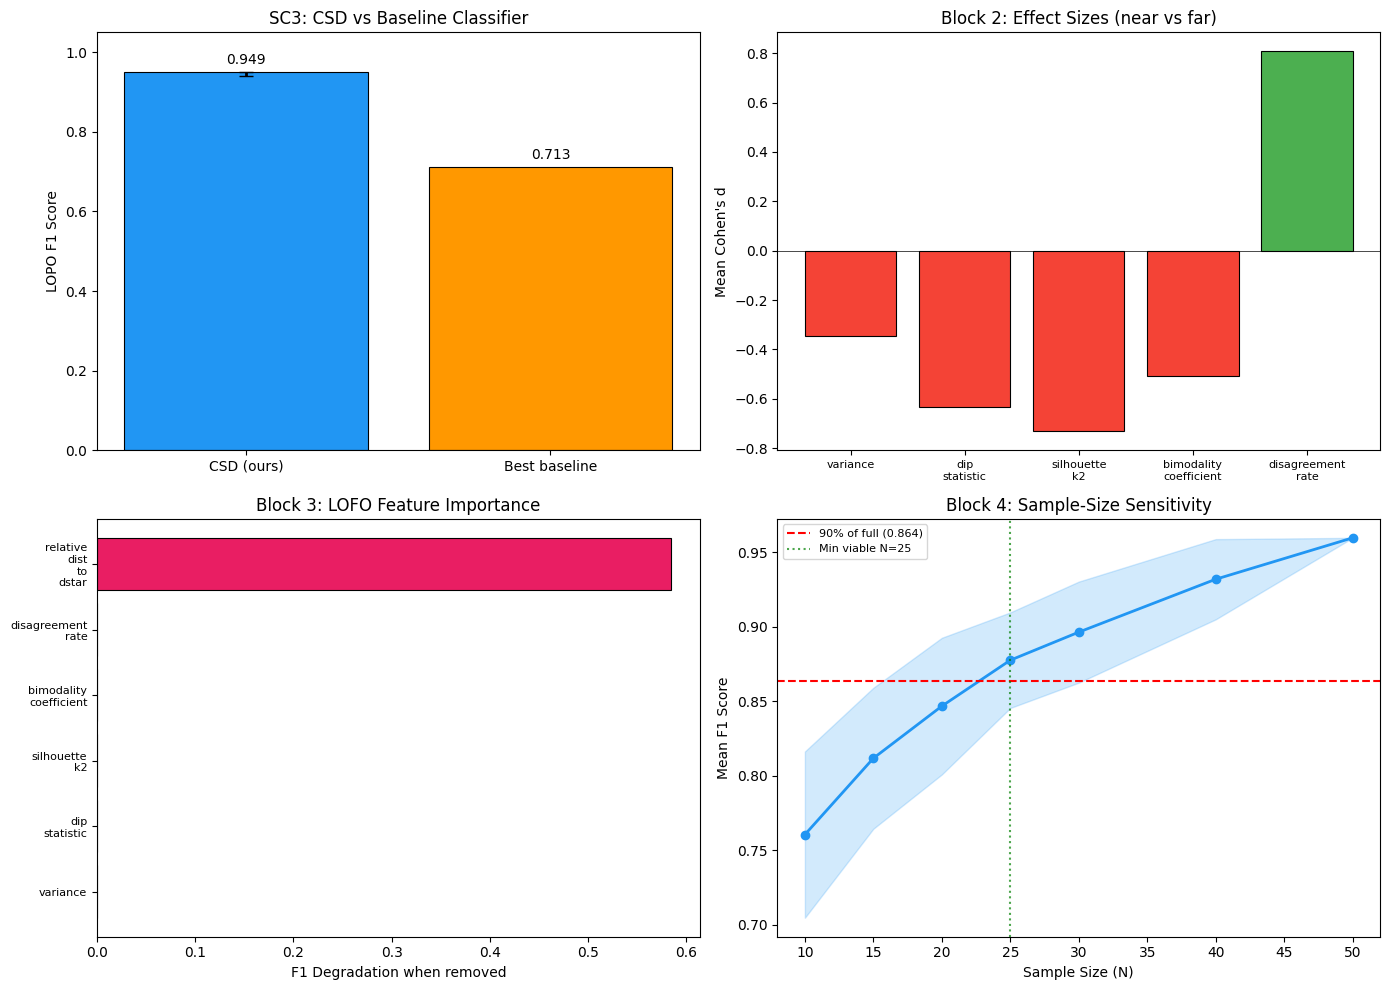

Saved evaluation_summary.png


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Panel 1: SC3 Classifier F1 comparison ──
ax = axes[0, 0]
labels = ["CSD (ours)", "Best baseline"]
vals = [sc3_agg["sc3_csd_lopo_f1"], sc3_agg["sc3_best_baseline_f1"]]
colors_bar = ["#2196F3", "#FF9800"]
bars = ax.bar(labels, vals, color=colors_bar, edgecolor="black", linewidth=0.8)
# CI whiskers for CSD (abs to handle BCa edge cases)
yerr_lo = abs(sc3_agg["sc3_csd_lopo_f1"] - sc3_agg["sc3_csd_lopo_f1_ci_lower"])
yerr_hi = abs(sc3_agg["sc3_csd_lopo_f1_ci_upper"] - sc3_agg["sc3_csd_lopo_f1"])
ax.errorbar(0, sc3_agg["sc3_csd_lopo_f1"],
            yerr=[[yerr_lo], [yerr_hi]],
            fmt="none", color="black", capsize=5, linewidth=2)
ax.set_ylabel("LOPO F1 Score")
ax.set_title("SC3: CSD vs Baseline Classifier")
ax.set_ylim(0, 1.05)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.02, f"{v:.3f}", ha="center", fontsize=10)

# ── Panel 2: Effect sizes by indicator ──
ax = axes[0, 1]
ind_labels = [ind.replace("_", "\n") for ind in indicators]
cd_vals = [eff_agg.get(f"effect_size_mean_cohen_d_{ind}", 0) for ind in indicators]
x = np.arange(len(indicators))
ax.bar(x, cd_vals, color=["#4CAF50" if v > 0 else "#F44336" for v in cd_vals], edgecolor="black", linewidth=0.8)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(ind_labels, fontsize=8)
ax.set_ylabel("Mean Cohen's d")
ax.set_title("Block 2: Effect Sizes (near vs far)")

# ── Panel 3: LOFO Feature Ablation ──
ax = axes[1, 0]
if abl_res:
    feat_names = [r["feature"].replace("_zt", "").replace("_", "\n") for r in abl_res["lofo"]]
    degradations = [r["degradation"] for r in abl_res["lofo"]]
    x = np.arange(len(feat_names))
    colors_lofo = ["#E91E63" if d > 0 else "#9E9E9E" for d in degradations]
    ax.barh(x, degradations, color=colors_lofo, edgecolor="black", linewidth=0.8)
    ax.set_yticks(x)
    ax.set_yticklabels(feat_names, fontsize=8)
    ax.set_xlabel("F1 Degradation when removed")
    ax.axvline(0, color="black", linewidth=0.5)
ax.set_title("Block 3: LOFO Feature Importance")

# ── Panel 4: Sample-size sensitivity curve ──
ax = axes[1, 1]
Ns = [r["N"] for r in sens_res]
f1s = [r["mean_f1"] for r in sens_res]
stds = [r["std_f1"] for r in sens_res]
ax.plot(Ns, f1s, "o-", color="#2196F3", linewidth=2, markersize=6)
ax.fill_between(Ns, [f - s for f, s in zip(f1s, stds)], [f + s for f, s in zip(f1s, stds)],
                alpha=0.2, color="#2196F3")
ax.axhline(f1s[-1] * 0.9, color="red", linestyle="--", label=f"90% of full ({f1s[-1]*0.9:.3f})")
ax.axvline(min_N, color="green", linestyle=":", alpha=0.7, label=f"Min viable N={min_N}")
ax.set_xlabel("Sample Size (N)")
ax.set_ylabel("Mean F1 Score")
ax.set_title("Block 4: Sample-Size Sensitivity")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("evaluation_summary.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved evaluation_summary.png")